# 99 — Project Summary: Europe Momentum Backtest

## Objective

This notebook summarizes the full project.

The objective is to build and evaluate a long-only European equity momentum strategy.

The strategy :
- uses a fixed universe of 24 European large-cap stocks
- computes a 12-1 momentum signal
- selects the top 30% stocks each month
- applies equal weights
- compares performance against the FEZ benchmark

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load Project Outputs

We load the main outputs generated throughout the project:
- backtest summary
- performance metrics
- transaction cost analysis
- in-sample / out-of-sample metrics
- robustness grid

In [2]:
backtest_summary = pd.read_csv("../data/backtest_summary.csv", index_col=0, parse_dates=True)
performance_metrics = pd.read_csv("../data/performance_metrics.csv", index_col=0)
transaction_costs = pd.read_csv("../data/transaction_costs_summary.csv", index_col=0, parse_dates=True)
oos_metrics = pd.read_csv("../data/oos_metrics.csv", index_col=0)
robustness_grid = pd.read_csv("../data/robustness_grid.csv")

## 2. Methodology

The project follows a complete quantitative backtesting workflow :

1. Data collection and cleaning  
2. Monthly return computation  
3. Momentum 12-1 factor construction  
4. Long-only portfolio construction  
5. Benchmark comparison with FEZ  
6. Performance metrics  
7. Risk analysis  
8. Transaction costs  
9. In-sample / out-of-sample validation  
10. Parameter robustness analysis  

The strategy is evaluated not only on raw performance, but also on risk, costs and robustness.

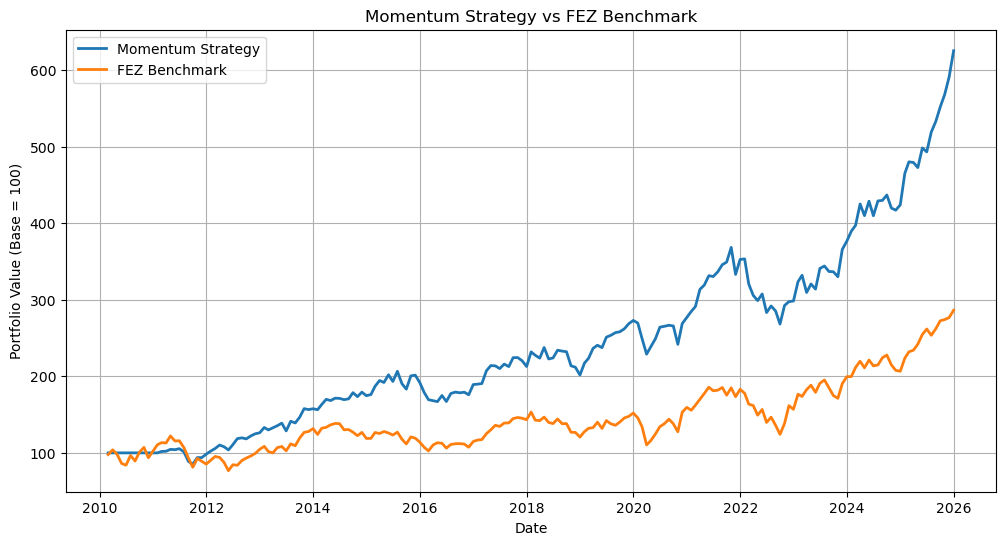

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(backtest_summary["Strategy Equity"], label="Momentum Strategy", linewidth=2)
plt.plot(backtest_summary["FEZ Equity"], label="FEZ Benchmark", linewidth=2)

plt.title("Momentum Strategy vs FEZ Benchmark")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Base = 100)")
plt.legend()
plt.grid(True)

plt.show()

## 3. Main Performance Results

The strategy is compared with the FEZ benchmark using CAGR, annualized volatility and Sharpe ratio.

Key results:
- Momentum strategy CAGR : 12.28%
- FEZ benchmark CAGR : 7.02%
- Momentum strategy volatility : 14.96%
- FEZ benchmark volatility : 20.56%
- Momentum strategy Sharpe ratio : 0.85
- FEZ benchmark Sharpe ratio : 0.42

In [4]:
performance_metrics

,Momentum Strategy,FEZ Benchmark
CAGR,0.1228,0.0702
Annualized Volatility,0.1496,0.2056
Sharpe Ratio,0.8479,0.4245


## 4. Risk and Transaction Costs

The risk analysis shows that the strategy has a lower maximum drawdown than the benchmark:

- Momentum strategy max drawdown : -27.19%
- FEZ benchmark max drawdown : -37.23%

Transaction costs were modeled using 10 bps per traded amount.

After transaction costs, the strategy remains profitable:
- Final gross equity : 614.25
- Final net equity : 572.90
- Average monthly turnover : 39.49%

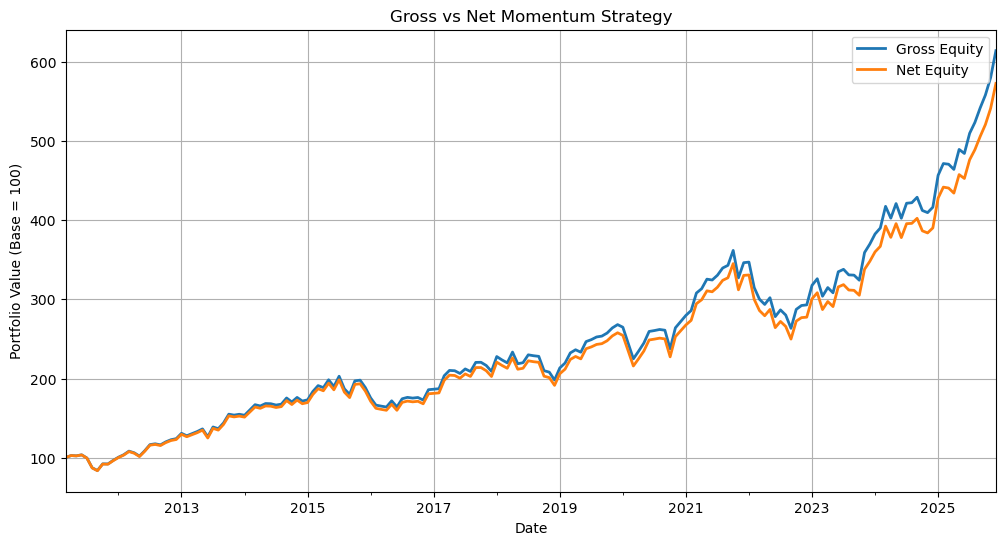

In [5]:
transaction_costs[["Gross Equity", "Net Equity"]].plot(figsize=(12, 6), linewidth=2)

plt.title("Gross vs Net Momentum Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Base = 100)")
plt.grid(True)
plt.show()

## 5. In-Sample / Out-of-Sample Validation

The strategy was tested across two non-overlapping periods:

- In-sample : 2012–2018
- Out-of-sample : 2019–2025

The strategy outperformed FEZ in both periods.

Out-of-sample results are especially important because they suggest that the momentum signal remains effective in a later market environment.

In [6]:
oos_metrics

,IS Momentum Strategy,IS FEZ Benchmark,OOS Momentum Strategy,OOS FEZ Benchmark
CAGR,0.1030,0.0425,0.1652,0.1237
Annualized Volatility,0.1454,0.1633,0.1578,0.2097
Sharpe Ratio,0.7803,0.3845,1.1096,0.6950


## 6. Parameter Robustness

The strategy was tested across several parameter combinations :

- momentum windows : 6-1, 9-1, 12-1
- selection thresholds : top 20%, 30%, 40%

The objective was not to optimize parameters, but to check whether the strategy remains reasonably effective under different assumptions.

In [7]:
robustness_grid

,Momentum Window,Top Quantile,Sharpe Ratio
0,6-1,Top 20%,0.665650
1,6-1,Top 30%,0.826117
2,6-1,Top 40%,0.827982
3,9-1,Top 20%,0.897546
4,9-1,Top 30%,0.920280
5,9-1,Top 40%,0.927341
6,12-1,Top 20%,0.736451
7,12-1,Top 30%,0.877445
8,12-1,Top 40%,0.970058


## 7. Limitations

This project has several limitations :

- The stock universe is fixed and composed of large European companies that are still actively traded today. This may introduce a moderate survivorship bias because companies that disappeared, delisted or strongly underperformed during the period are not included in the analysis.

- The backtest uses historical adjusted prices from Yahoo Finance.

- Transaction costs are simplified using a constant 10 bps assumption.

- The strategy assumes perfect execution at monthly closing prices, which may differ from real trading conditions.

- The strategy does not include liquidity constraints or market impact.

- The benchmark comparison is limited to FEZ.

Despite these limitations, the project follows a structured quantitative workflow and provides a solid first implementation of a European equity momentum strategy.

## Final Conclusion

This project implemented a complete European equity momentum backtest.

The strategy outperformed the FEZ benchmark in terms of return, volatility and Sharpe ratio.

The analysis was extended beyond a simple equity curve by including :
- risk analysis
- transaction costs
- in-sample / out-of-sample validation
- parameter robustness

Overall, the project suggests that the momentum signal is reasonably robust across time and parameter choices, while remaining aware of important backtesting limitations such as survivorship bias and simplified implementation costs.